In [8]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

# Absolute dataset path
dataset_path = Path(r"C:\Users\Madesh\OneDrive\Desktop\BEU\deep_mri")
thermal_path = dataset_path / "Thermal"

# Train/Test folders (note: capital T)
splits = ["Train", "Test"]
classes = ["stroke", "normal"]

def convert_to_thermal(src_folder, dst_folder):
    dst_folder.mkdir(parents=True, exist_ok=True)
    images = list(src_folder.glob("*.*"))  # match ANY extension
    print(f"Converting {src_folder.relative_to(dataset_path)} ... Found {len(images)} files")

    for img_path in tqdm(images):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"⚠️ Skipped unreadable file: {img_path.name}")
            continue

        # Apply thermal effect
        thermal_img = cv2.applyColorMap(img, cv2.COLORMAP_JET)

        # Save image
        save_path = dst_folder / (img_path.stem + "_thermal.png")
        cv2.imwrite(str(save_path), thermal_img)

# Loop through Train/Test and stroke/normal
for split in splits:
    for cls in classes:
        src_dir = dataset_path / split / cls
        dst_dir = thermal_path / split / cls
        convert_to_thermal(src_dir, dst_dir)

print("✅ Thermal image conversion complete!")
print(f"Thermal dataset stored at: {thermal_path}")


Converting Train\stroke ... Found 1326 files


100%|██████████████████████████████████████████████████████████████████████████████| 1326/1326 [00:55<00:00, 23.90it/s]


Converting Train\normal ... Found 1009 files


100%|██████████████████████████████████████████████████████████████████████████████| 1009/1009 [00:56<00:00, 17.93it/s]


Converting Test\stroke ... Found 441 files


100%|████████████████████████████████████████████████████████████████████████████████| 441/441 [00:18<00:00, 23.58it/s]


⚠️ Skipped unreadable file: fefff.m
Converting Test\normal ... Found 335 files


100%|████████████████████████████████████████████████████████████████████████████████| 335/335 [00:18<00:00, 17.99it/s]

✅ Thermal image conversion complete!
Thermal dataset stored at: C:\Users\Madesh\OneDrive\Desktop\BEU\deep_mri\Thermal


In [1]:
# SWIN TRANSFORMER

In [1]:
pip install timm torchsummary matplotlib



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Madesh\AppData\Local\Temp\ipykernel_11120\400806559.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


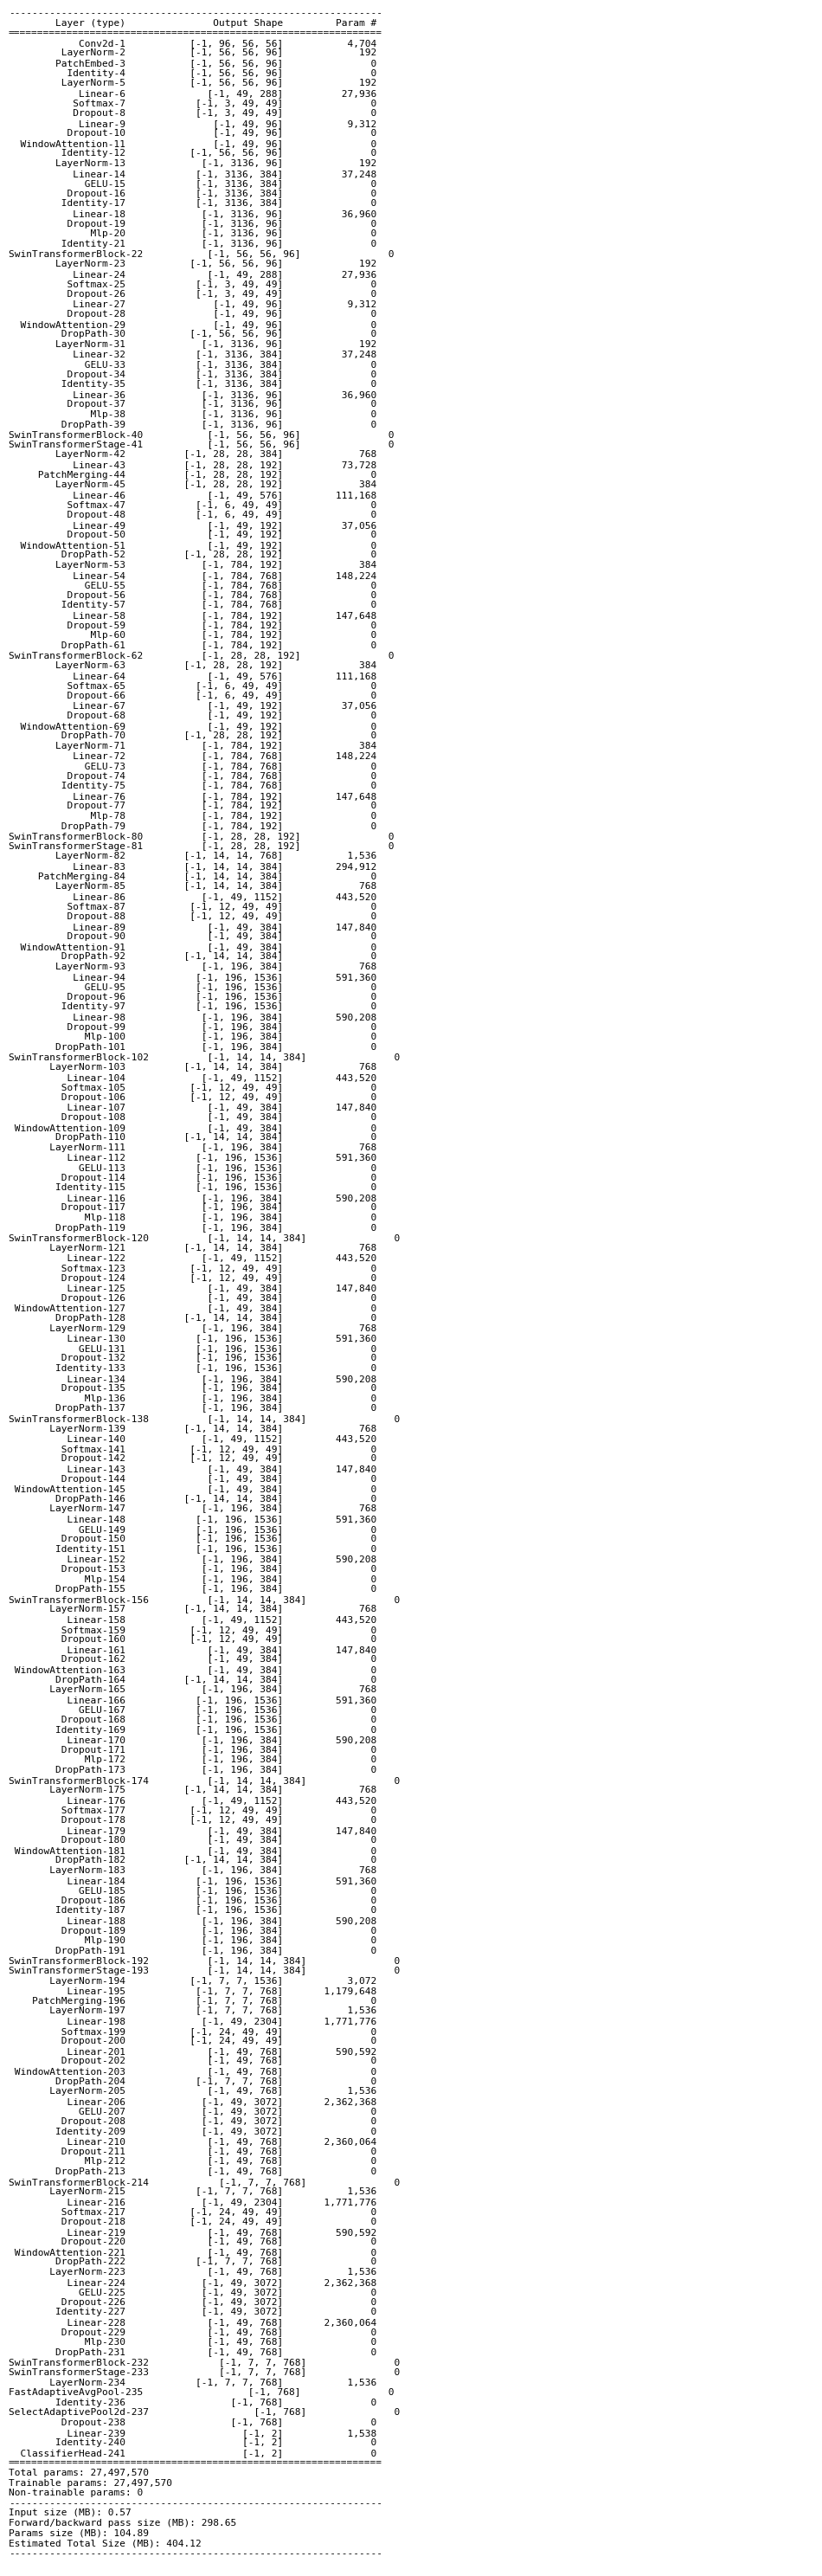

In [3]:
import timm
from torchsummary import summary
import matplotlib.pyplot as plt
import torch
import io
import contextlib

# Load Swin Tiny model
model_name = "swin_tiny_patch4_window7_224"
model = timm.create_model(model_name, pretrained=True, num_classes=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Capture printed summary into a string
f = io.StringIO()
with contextlib.redirect_stdout(f):
    summary(model, (3, 224, 224), device=str(device))
summary_text = f.getvalue()

# Save as image
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis("off")
ax.text(0, 1, summary_text, va="top", family="monospace", fontsize=8)
plt.tight_layout()
plt.savefig("swin_tiny_architecture.png", dpi=300)
plt.show()


In [5]:
pip install torchview



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import timm
from torchview import draw_graph

model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=2)
graph = draw_graph(model, input_size=(1, 3, 224, 224), expand_nested=True)
graph.visual_graph.render("swin_tiny_architecture", format="png")  # saves PNG


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [7]:
pip install torchviz


Note: you may need to restart the kernel to use updated packages.Collecting torchviz




[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
from torchviz import make_dot
import timm

# Load your model
model = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=2)
x = torch.randn(1, 3, 224, 224)  # dummy input

# Forward pass
y = model(x)

# Create graph
dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("swin_tiny_architecture", format="png")  # saves as PNG in current folder


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH